# Build Regression Model Using Sequential API

If output varibale is not discrete in nature, its continuous, insequence or in time series.

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

In [5]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [6]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [7]:
X=housing["data"]
y=housing["target"]

In [8]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [9]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_Other, y_train, y_Other = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Split into validation and testing
X_val, X_test, y_val, y_test = train_test_split(X_Other, y_Other, test_size=0.5, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [15]:
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)

In [16]:
X_Other.shape[0]//2

2064

In [17]:
X_train.shape, X_val.shape, X_test.shape

((16512, 8), (2064, 8), (2064, 8))

In [18]:
y_train.shape, y_val.shape, y_test.shape

((16512,), (2064,), (2064,))

In [19]:
# Create Model Regression
model = keras.models.Sequential([
    keras.layers.Input(shape=X_train.shape[1:], name = "Input_Layer"),
    keras.layers.Dense(30, activation="relu", name = "HL1"),
    keras.layers.Dense(30, activation="relu", name = "HL2"),
    keras.layers.Dense(1, activation="linear", name = "Output_Layer")
    ])

In [20]:
from keras.optimizers import Adam

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [22]:
chk_pt=ModelCheckpoint("california_housing.keras",
              save_best_only=True,
              monitor="val_loss")

In [23]:
early_stop=EarlyStopping(monitor="val_loss",
                         patience=10,
                         restore_best_weights=True)

In [ ]:
call_backs = [chk_pt, early_stop]

In [24]:
model.compile(loss="mse",
              optimizer=Adam(learning_rate=1e-3),
              metrics=["RootMeanSquaredError"])

In [26]:
history = model.fit(X_train_scaled, y_train, epochs=50,
          batch_size =64, validation_data=(X_val_scaled, y_val),
                    callbacks=call_backs)

Epoch 1/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 1.7512 - loss: 3.2533 - val_RootMeanSquaredError: 0.7920 - val_loss: 0.6273
Epoch 2/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - RootMeanSquaredError: 0.7383 - loss: 0.5453 - val_RootMeanSquaredError: 0.6757 - val_loss: 0.4565
Epoch 3/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6499 - loss: 0.4224 - val_RootMeanSquaredError: 0.6447 - val_loss: 0.4157
Epoch 4/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - RootMeanSquaredError: 0.6246 - loss: 0.3902 - val_RootMeanSquaredError: 0.6326 - val_loss: 0.4002
Epoch 5/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - RootMeanSquaredError: 0.6126 - loss: 0.3753 - val_RootMeanSquaredError: 0.6254 - val_loss: 0.3911
Epoch 6/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6041 - loss: 0.3650 - val_RootMeanSquaredError: 0.6202 - val_loss: 0.3846
Epoch 7/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - RootMeanSquaredError: 0.5982 - los

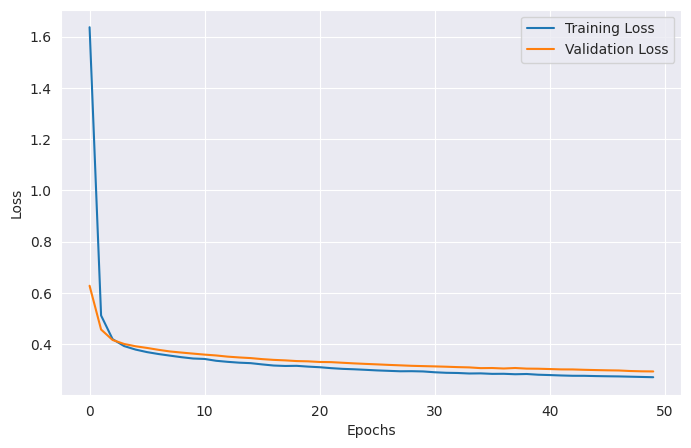

In [27]:
# Generate the loss vs val_loss

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

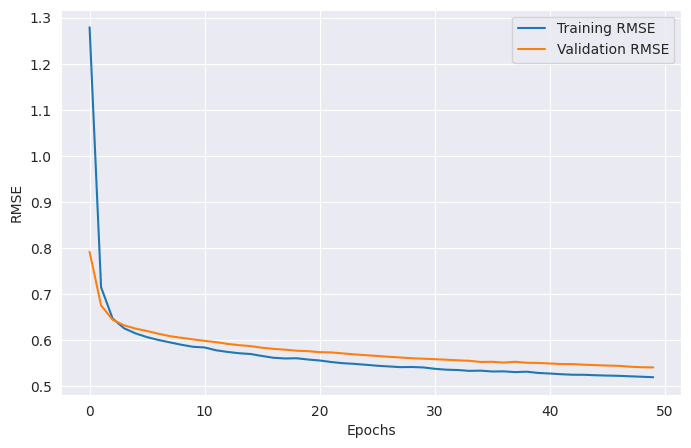

In [28]:
# Generate the accuracy vs val_accuracy Graph

plt.figure(figsize=(8,5))
plt.plot(history.history["RootMeanSquaredError"], label="Training RMSE")
plt.plot(history.history["val_RootMeanSquaredError"], label="Validation RMSE")
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [37]:
from keras.models import load_model
loaded_model = load_model("california_housing.keras")

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ HL1 (Dense)                     │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HL2 (Dense)                     │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,695 (14.44 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,464 (9.63 KB)

In [30]:
from tensorflow.keras.utils import plot_model

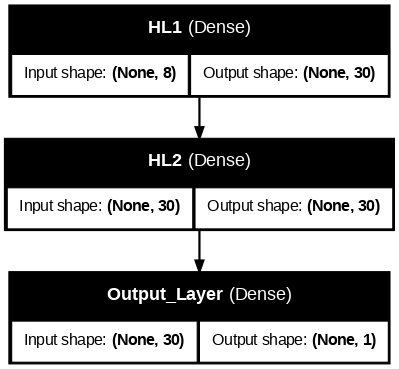

In [31]:
plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True, dpi=80)

In [32]:
loss, rmse = model.evaluate(X_test_scaled, y_test)
print(f"Test Loss: {loss:.2f}")
print(f"Test RMSE: {rmse*100:.2f}%")

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5357 - loss: 0.2874  
Test Loss: 0.30
Test RMSE: 54.59%


In [33]:
y_pred=model.predict(X_test_scaled)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [34]:
print(f"Actual: {y_test[:5]}")
print(f"Predicted: {y_pred[:5].flatten()}")

Actual: [2.385 3.297 0.952 2.451 0.641]
Predicted: [2.8552365 1.995272  1.3958955 2.5292506 0.9251902]
